**AICA X DATACAMP CAPSTONE MACHINE LEARNING PROJECT - RESIDENTIAL PROPERTY PRICE PREDICTOR**

**Kaggle Dataset link:** https://www.kaggle.com/datasets/harishkumardatalab/housing-price-prediction


**Setup**

In [108]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split,KFold,cross_validate,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
#     root_mean_squared_error,
    r2_score
)

In [109]:
#configuration setup
pd.set_option("display.max_columns",None)

plt.rcParams.update(
    {
    "axes.titlesize":12,
    "axes.labelsize":12,
    "xtick.labelsize":12,
    "ytick.labelsize":12
    }
)

csv_file_path = "Housing.csv"
RANDOM_STATE = 42
TARGET_COL = "price"

**Load Data**

In [110]:
house_df = pd.read_csv(csv_file_path)
house_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


**Exploratory Data Analysis(EDA)**

In [111]:
house_df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [112]:
#dataset overview
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [113]:
num_cols = house_df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = house_df.select_dtypes(include=[np.object]).columns.tolist()

print(f"Target Column: {TARGET_COL}")
print(f'Numerical Columns: {num_cols}')
print(f'Categorical Columns: {cat_cols}')

Target Column: price
Numerical Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical Columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [114]:
#Handling Missing Values
house_df.isna().sum()
#visualize the missing values
#house_df.isna().sum.plot.bar()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

**_Comment - There are no missing values contained in the dataset_**

In [116]:
#check for duplicates
duplicate_data = house_df.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_data}")

Number of duplicated rows: 0


In [117]:
house_df.shape

(545, 13)

In [118]:
house_df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,545.000,545.000,545.000,545.000,545.000,545.000
mean,4766729.248,5150.541,2.965,1.286,1.806,0.694
std,1870439.616,2170.141,0.738,0.502,0.867,0.862
min,1750000.000,1650.000,1.000,1.000,1.000,0.000
25%,3430000.000,3600.000,2.000,1.000,1.000,0.000
50%,4340000.000,4600.000,3.000,1.000,2.000,0.000
75%,5740000.000,6360.000,3.000,2.000,2.000,1.000
max,13300000.000,16200.000,6.000,4.000,4.000,3.000


**Data Visualization**

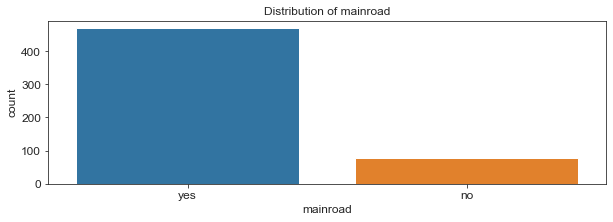

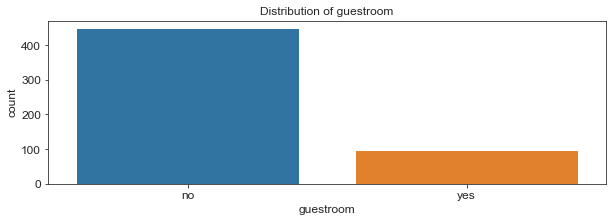

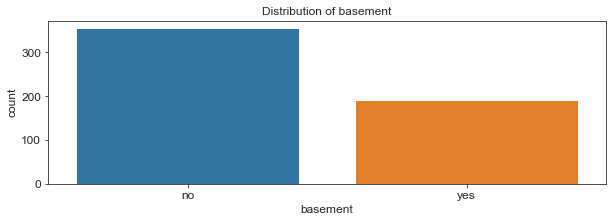

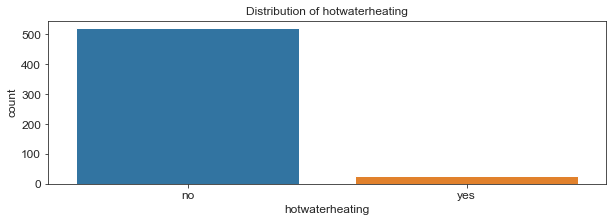

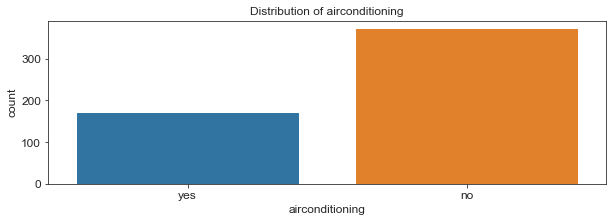

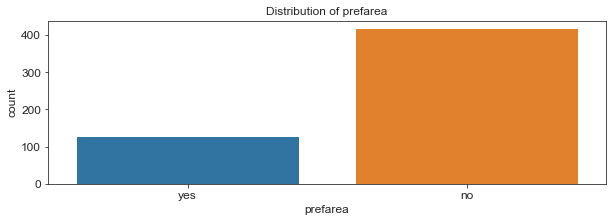

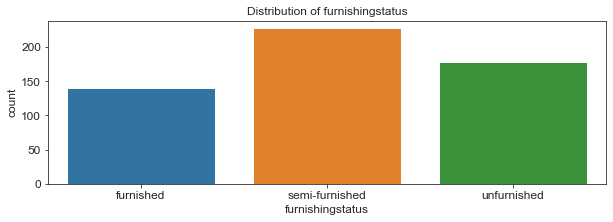

In [119]:
#countplot for categorical columns
sns.set_style("ticks")
for col in cat_cols:
    plt.figure(figsize=(10,3))
    sns.countplot(x=col,data=house_df)
    plt.title(f"Distribution of {col}")
    plt.show()

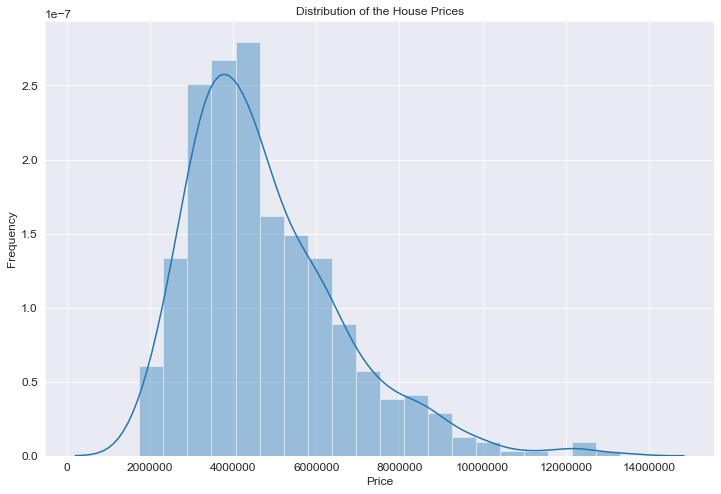

In [120]:
#Visualization of the distribution of the target column
sns.set_style("darkgrid")
plt.figure(figsize=(12,8))
sns.distplot(house_df[TARGET_COL],kde=True,bins=20)
plt.ticklabel_format(style="plain",axis="x")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of the House Prices")
plt.show()

In [121]:
# unique_cat_cols = [house_df[col].value_counts() for col in cat_cols]
# unique_cat_cols

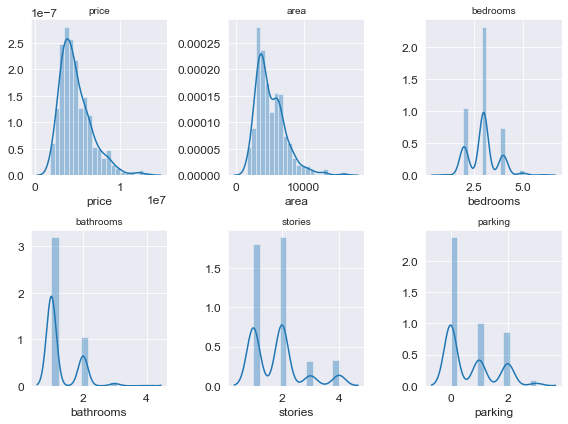

In [122]:
#histogram distribution plot for numerical columns
fig, axes = plt.subplots(2,3, figsize=(8,6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.distplot(house_df[col],kde=True,ax=axes[i])
    axes[i].set_title(col,fontsize=10)

plt.tight_layout()
plt.show()

In [123]:
#Identify highly correlated features & feature relationships
corr_heatmap = house_df[num_cols].corr()
corr_heatmap

,price,area,bedrooms,bathrooms,stories,parking
price,1.000,0.536,0.366,0.518,0.421,0.384
area,0.536,1.000,0.152,0.194,0.084,0.353
bedrooms,0.366,0.152,1.000,0.374,0.409,0.139
bathrooms,0.518,0.194,0.374,1.000,0.326,0.177
stories,0.421,0.084,0.409,0.326,1.000,0.046
parking,0.384,0.353,0.139,0.177,0.046,1.000


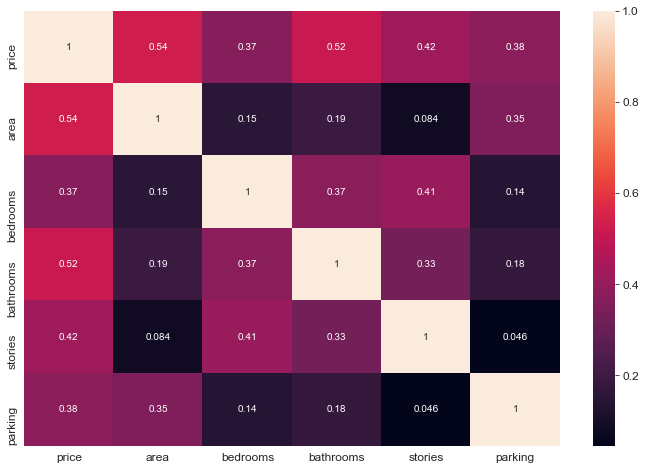

In [124]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_heatmap,annot=True)
plt.show()

In [125]:
#Correlation pf the features with the target price
corr_with_target = house_df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("Correlation with target:")
print(corr_with_target)

Correlation with target:
price       1.000
area        0.536
bathrooms   0.518
stories     0.421
parking     0.384
bedrooms    0.366
Name: price, dtype: float64


---

**NOTES FROM THE EXPLORATORY DATA ANALYSIS**

- Dataset has 6 numerical features and 7 categorical features
- There are no missing values present in the dataset
- Area, bathrooms,stories are stronger predictors of price though Area is the strongest predictor amongst the three as seen from the correlation heatmap

---

**Data Preprocessing**

In [126]:
#seperate features and target
x = house_df.drop(columns=[TARGET_COL])
y = house_df[TARGET_COL]

In [127]:
x.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [128]:
y.head()

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64

In [129]:
#split the dataset into train and test set
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [130]:
print("Train shape:", x_train.shape)
print("Test shape:",x_test.shape)

Train shape: (436, 12)
Test shape: (109, 12)


**Preprocessing Pipeline**
- Pipelines created to prevent data leakage and easily connected workflow

In [131]:
numerical_features = x_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = x_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical features: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [132]:
#numerical features - preprocessing steps
numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler()) #feature scaling 
    ]
)

#categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore")) #categorical variables coversion to a numerical values
    ]
)

#preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

**Baseline Model**

In [133]:
#Baseline model pipeline for preprocessing and model training
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

**Model Training for the Baseline Model**

In [134]:
#preprocess the data and train the baseline model
baseline_pipe.fit(x_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['area', 'bedrooms',
                                                   'bathrooms', 'stories',
                                                   'parking']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['mainroad', 'guestroom',
                                                   'basement',
                                                   'hotwaterheating',
                                                   'airconditioning',
                                                   'prefarea',
                                                   'furnishingstatus'])])),
                ('model', LinearRegression())])

**Evaluate the BASELINE MODEL**

In [135]:
#model predictions with the train and test data
train_baseline_pred = baseline_pipe.predict(x_train)
test_baseline_pred = baseline_pipe.predict(x_test)

In [136]:
#predicted target values (price)
train_baseline_pred[:5]

array([7109165.83869914, 6882951.80434331, 4815249.78634876,
       3990061.64537982, 3238924.34106256])

In [137]:
#actual target values (price)
y_train[:5]

46     7525000
93     6300000
335    3920000
412    3430000
471    3010000
Name: price, dtype: int64

**Evaluation Metrics for the Baseline Model**

In [138]:
#training data metrics
train_baseline_mae = mean_absolute_error(y_train,train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("=== BASELINE METRICS FOR THE TRAINING DATA (Linear Regression) ===")
print(f"MAE: {train_baseline_mae:.3f}")
print(f"R2: {train_baseline_r2:.3f}\n")

#test data metrics
test_baseline_mae = mean_absolute_error(y_test,test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("=== BASELINE METRICS FOR THE TEST DATA (Linear Regression) ===")
print(f"MAE: {test_baseline_mae:.3f}")
print(f"R2: {test_baseline_r2:.3f}")

=== BASELINE METRICS FOR THE TRAINING DATA (Linear Regression) ===
MAE: 719242.894
R2: 0.686

=== BASELINE METRICS FOR THE TEST DATA (Linear Regression) ===
MAE: 970043.404
R2: 0.653


- **Inference from the Evaluation Metric**


Linear Regression Model shows a 65% variance in the housing prices across the dataset and the MAE is acceptable in relation to the scale of the Prices in the dataset

In [139]:
#user-defined plot function for visualization
def plot_model_prediction(model_pred,model_name):
    '''Model Plot to Show the Relationship between 
        the Actual Prices and Predicted Prices'''
    plt.figure(figsize=(12,8))

    # scatter: actual vs predicted
    plt.scatter(y_test, model_pred, alpha=0.7)

    # perfect prediction line (y = x)
    min_val = min(min(y_test), min(model_pred))
    max_val = max(max(y_test), max(model_pred))
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"{model_name}: Actual vs Predicted Prices")

    plt.show()

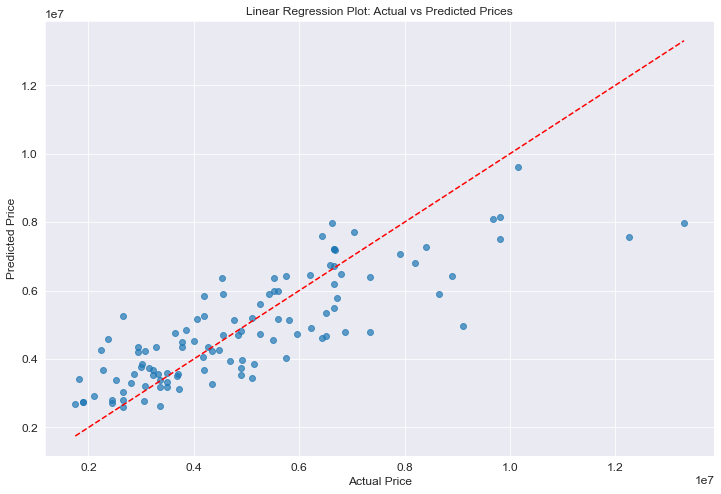

In [140]:
plot_model_prediction(test_baseline_pred,"Linear Regression Plot")

**Inference from the model plot**
- Predictions close to the red line are good predictions
- Predictions far from the red line are large errors

**INTERMEDIATE MODEL**

In [141]:
#Intermediate model pipeline
dt_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeRegressor(max_depth=3, min_samples_leaf=10, random_state=RANDOM_STATE))
    ]
)

In [142]:
#preprocess data and model training
dt_pipe.fit(x_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['area', 'bedrooms',
                                                   'bathrooms', 'stories',
                                                   'parking']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['mainroad', 'guestroom',
                                                   'basement',
                                                   'hotwaterheating',
                                                   'airconditioning',
                                                   'prefarea',
                                                   'furnishingstatus'])])),
                ('model',
                 DecisionTreeRegressor(max_depth=3, min_samples_leaf=10,
                                       random_state=42))])

In [143]:
#model predictions with train and test data
dt_train_regressor_pred = dt_pipe.predict(x_train)
dt_test_regressor_pred = dt_pipe.predict(x_test)

In [144]:
#display first five predicted values/prices
dt_train_regressor_pred[:5]

array([7813733.52941176, 7813733.52941176, 4069085.61643836,
       3284130.20833333, 3284130.20833333])

In [145]:
#actual target values/prices
y_train[:5]

46     7525000
93     6300000
335    3920000
412    3430000
471    3010000
Name: price, dtype: int64

**Metrics Evaluation of Intermediate Model**

In [146]:
#mean absolute error for train data
dt_train_regressor_mae = mean_absolute_error(y_train, dt_train_regressor_pred)
dt_train_regressor_r2 = r2_score(y_train, dt_train_regressor_pred)
print("=== INTERMEDIATE METRIC FOR TRAINING DATA (Decision Tree Regression) ===")
print(f"MAE: {dt_train_regressor_mae:.3f}")
print(f"R2: {dt_train_regressor_r2:.3f}\n")

#mean absolute error for test data
dt_test_regressor_mae = mean_absolute_error(y_test, dt_test_regressor_pred)
dt_test_regressor_r2 = r2_score(y_test, dt_test_regressor_pred)

print("=== INTERMEDIATE METRIC FOR TEST DATA (Decision Tree Regression) ===")
print(f"MAE: {dt_test_regressor_mae:.3f}")
print(f"R2: {dt_test_regressor_r2: .3f}")

=== INTERMEDIATE METRIC FOR TRAINING DATA (Decision Tree Regression) ===
MAE: 855352.310
R2: 0.560

=== INTERMEDIATE METRIC FOR TEST DATA (Decision Tree Regression) ===
MAE: 1265498.614
R2:  0.451


- Inference from the Evaluation Metric


The Decision Tree Regressor model shows a 45% variance in the housing prices across the dataset but the MAE is too large when compared to the scale of the prices dataset(large prediction errors)

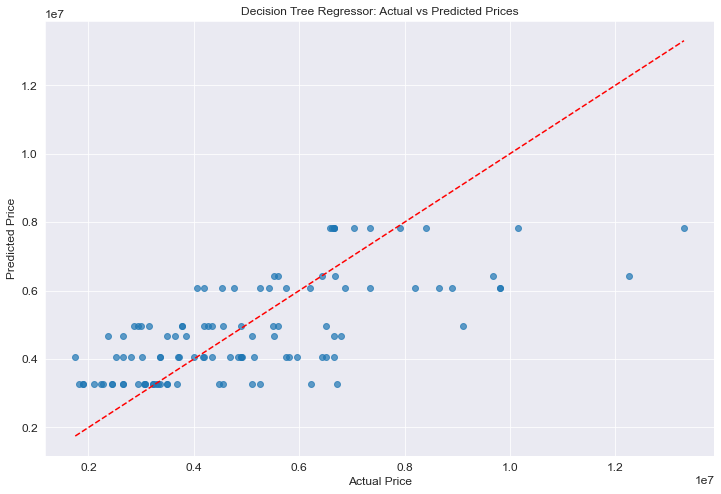

In [147]:
plot_model_prediction(dt_test_regressor_pred,"Decision Tree Regressor")

In [148]:
#Getting the feature importance scores
dt_model = dt_pipe.named_steps['model'] #access the decision tree regressor object
importances = dt_model.feature_importances_

# Extract the column names after preprocessing
feature_names = dt_pipe.named_steps['preprocess'].get_feature_names_out()

#Create a DataFrame of the Features and the Importance Scores 
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print(f"=== The Feature Importance Scores ===\n{feature_importance_df}")

=== The Feature Importance Scores ===
                                 Feature  Importance
0                              num__area       0.632
1                         num__bathrooms       0.252
2      cat__furnishingstatus_unfurnished       0.047
3                cat__airconditioning_no       0.036
4               cat__airconditioning_yes       0.033
5                           num__stories       0.000
6               cat__hotwaterheating_yes       0.000
7   cat__furnishingstatus_semi-furnished       0.000
8        cat__furnishingstatus_furnished       0.000
9                      cat__prefarea_yes       0.000
10                      cat__prefarea_no       0.000
11               cat__hotwaterheating_no       0.000
12                          num__parking       0.000
13                         num__bedrooms       0.000
14                      cat__basement_no       0.000
15                    cat__guestroom_yes       0.000
16                     cat__guestroom_no       0.000
17      